In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import warnings

if '../' not in sys.path:
    sys.path.append('../')

In [17]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import root_scalar

### directory with N_eff results

In [4]:
neff_results_dir = '../output/results/'

### Loop over directories to find all parameter points and load results

In [5]:
mass_dirs = []
mass_charge_dirs = []

for name in os.listdir(neff_results_dir):
    if os.path.isdir(os.path.join(neff_results_dir, name)):
        mass_dirs.append(os.path.join(neff_results_dir, name))


for md in mass_dirs:
    for name in os.listdir(md):
        if os.path.isdir(os.path.join(md, name)):
            mass_charge_dirs.append(os.path.join(md, name))
    
    

In [6]:
num_param_points = len(mass_charge_dirs)

masses = np.zeros(num_param_points)
charges = np.zeros(num_param_points)
N_eff = np.zeros(num_param_points)
Delta_N_eff = np.zeros(num_param_points)
Delta_N_eff_dso = np.zeros(num_param_points)


for (i, mcd) in enumerate(mass_charge_dirs):
    result_file = os.path.join(mcd, 'result.npz')
    if os.path.exists(result_file):
        result = np.load(result_file)

        masses[i] = result['m_mcp']
        charges[i] = result['Q']
        N_eff[i] = result['N_eff_bsm']
        Delta_N_eff[i] = result['Delta_Neff']
        Delta_N_eff_dso[i] = result['DNeff_dso']

### Plots

In [7]:
unique_masses = np.unique(masses)

N_eff_results_dict = dict()
Delta_N_eff_interp_dict = dict()

for um in unique_masses:
    charges_um = charges[np.where(masses == um)]
    N_eff_um = N_eff[np.where(masses == um)]
    Delta_N_eff_um = Delta_N_eff[np.where(masses == um)]
    Delta_N_eff_dso_um = Delta_N_eff_dso[np.where(masses == um)]

    sort_order = charges_um.argsort()

    result_um = np.array([
        charges_um[sort_order], 
        N_eff_um[sort_order],
        Delta_N_eff_um[sort_order],
        Delta_N_eff_dso_um[sort_order]
    ])

    dne_I = interp1d(
        charges_um[sort_order], 
        Delta_N_eff_dso_um[sort_order], 
        bounds_error=False, 
        fill_value=(Delta_N_eff_dso_um[sort_order][0], Delta_N_eff_dso_um[sort_order][-1])
    )

    print(Delta_N_eff_dso_um[sort_order])

    N_eff_results_dict = N_eff_results_dict | {um:   result_um}   
    Delta_N_eff_interp_dict = Delta_N_eff_interp_dict | {um: dne_I}

[6.20417118e-04 1.03255280e-03 1.73653545e-03 2.96730476e-03
 5.17813691e-03 9.26810190e-03 1.72659038e-02 3.39839600e-02
 7.02439687e-02 1.55398579e-01 3.42472503e-01 7.04051071e-01
 1.26847153e+00 1.88512464e+00 2.37213106e+00 2.64335971e+00
 2.81380508e+00 2.98419552e+00]
[2.32534563e-04 3.82315687e-04 6.30498619e-04 1.04511767e-03
 1.74305323e-03 2.94801371e-03 5.02867337e-03 8.80734058e-03
 1.59400073e-02 3.00928007e-02 6.03807577e-02 1.29641369e-01
 2.93670451e-01 6.27419718e-01 1.14006516e+00 1.62427389e+00
 1.88666831e+00 1.95341198e+00]


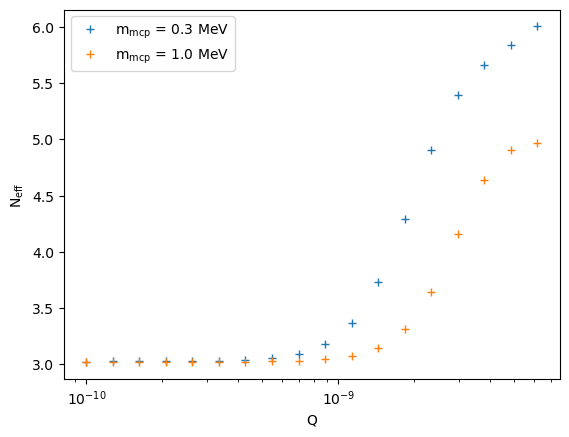

In [8]:
plt.plot(N_eff_results_dict[0.3][0], N_eff_results_dict[0.3][1], linestyle='none', marker='+', label=r'm$_{\rm mcp}$ = 0.3 MeV')

plt.plot(N_eff_results_dict[1.0][0], N_eff_results_dict[1.0][1], linestyle='none', marker='+', label=r'm$_{\rm mcp}$ = 1.0 MeV')

plt.xscale('log')

plt.xlabel('Q')
plt.ylabel(r'N$_{\rm eff}$')
plt.legend()
plt.show()

In [22]:
def get_DNeff_constraint_RHS(delta_neff_Interp, constraint):
    return lambda Q: delta_neff_Interp(Q) - constraint

def find_Q_DNeff_constraint(delta_neff_Interp, constraint):
    constraint_res = root_scalar(
         get_DNeff_constraint_RHS(delta_neff_Interp, constraint),
         bracket=(1e-10, 1e-8),
         x0=2e-9
    )

    return constraint_res.root

In [24]:
find_Q_DNeff_constraint(Delta_N_eff_interp_dict[0.3], 0.06)

6.525424699943838e-10

In [25]:
find_Q_DNeff_constraint(Delta_N_eff_interp_dict[1.0], 0.06)

1.1255915195043176e-09